In [43]:
import glob
import json
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 


results = []
for file in glob.glob("data/*.json"):
    with open(file, "r") as f:
        results.append(json.load(f))

df = pd.DataFrame(results)
df = df[df.method != "real_world"]
df['method'] = df['method'].replace('random_choice', 'Random')
df['method'] = df['method'].replace('louvain_communities', 'Louvain')
df['method'] = df['method'].replace('kernighan_lin_partition', 'Kernighan-Lin')
df['method'] = df['method'].replace('degree_centrality', 'Degree centrality')
df['method'] = df['method'].replace('cone_size', 'Cone size')

In [44]:
sns.set_context("talk")

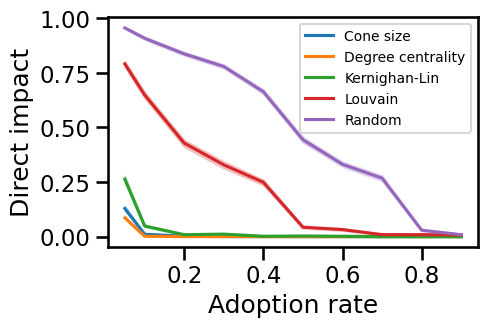

In [45]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(df, x="adoption_rate", y="direct_impact", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("Direct impact")
plt.legend(fontsize=10, title_fontsize=12)
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/sd_direct_impact.pdf", format="pdf")

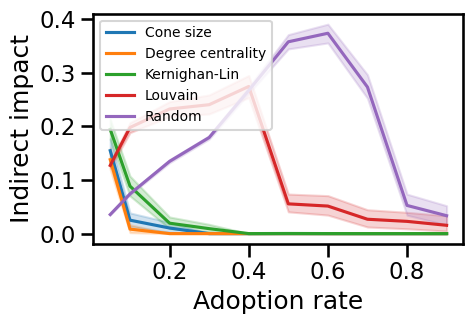

In [46]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(df, x="adoption_rate", y="indirect_impact", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("Indirect impact")
plt.legend(fontsize=10, title_fontsize=12, loc="upper left")
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/sd_indirect_impact.pdf", format="pdf")

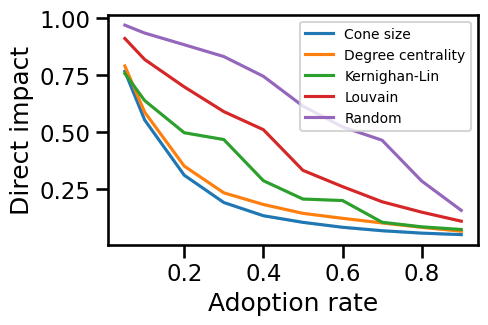

In [47]:
max_df = df.copy()
max_df["max_component"] = max_df["max_component"] / 79327 
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(max_df, x="adoption_rate", y="max_component", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("Direct impact")
plt.legend(fontsize=10, title_fontsize=12)
# Same margins for all figures
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/sd_no_vf_direct_impact.pdf", format="pdf")

In [48]:
import pickle
from src.graph import create_graph
from src.methods import CONE_SIZES

real_world = set(pickle.load(open("deployments/real_world_0.1_0.pkl", "rb")))
deployment = set(pickle.load(open("deployments/degree_centrality_0.1_0.pkl", "rb")))

graph = create_graph(edge_file="caida.txt", directed=True)


current = len(real_world.intersection(deployment))
print(current, current / len(deployment))


import networkx as nx
sizes = []

for node in deployment:
    sizes.append({
        "node": node,
        "depl": "deployment",
        "size": graph.degree(node),
        "type": "node_degree"
    })
    sizes.append({
        "node": node,
        "depl": "deployment",
        "size": CONE_SIZES[node],
        "type": "cone_size"
    })

TRANSIT_NODES = [node for node, data in graph.nodes(data=True) if data["type"] == "transit"]

for node in TRANSIT_NODES:
    sizes.append({
        "node": node,
        "depl": "all transit nodes",
        "size": graph.degree(node),
        "type": "node_degree"
    })
    sizes.append({
        "node": node,
        "depl": "all transit nodes",
        "size": CONE_SIZES[node],
        "type": "cone_size"
    })


size_df = pd.DataFrame(sizes)

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.histplot(
    size_df[size_df.type == "cone_size"], 
    x="size", 
    hue="depl", 
    bins=50,
    ax=ax
)
ax.set_yscale("log")
plt.xlabel("Cone size")
ax.get_legend().set_title("")
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/cone_size_cdf.pdf", format="pdf")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.histplot(
    size_df[(size_df.type == "node_degree")], 
    x="size", 
    hue="depl", 
    bins=50,
    ax=ax
)
ax.set_yscale("log")
plt.xlabel("Node degree")
ax.get_legend().set_title("")

fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/node_degree_cdf.pdf", format="pdf")
plt.close()


382 0.3048683160415004


In [49]:
len(size_df[(size_df.type == "cone_size") & (size_df.depl == "all transit nodes") & (size_df["size"] > 1000)])

683

In [50]:
len(size_df[(size_df.type == "cone_size") & (size_df.depl == "deployment") & (size_df["size"] > 1000)])

370

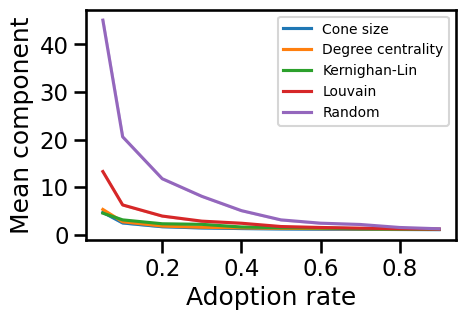

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(df, x="adoption_rate", y="average_component", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("Mean component")
plt.legend(fontsize=10, title_fontsize=12)
fig.subplots_adjust(
    left=0.24,
    right=0.96,
    bottom=0.24,
    top=0.94
)
plt.savefig("figures/average_component.pdf", format="pdf")

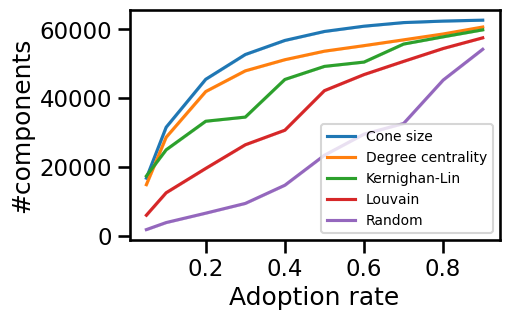

In [52]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(df, x="adoption_rate", y="number_of_components", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("#components")
plt.legend(fontsize=10, title_fontsize=12)
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/number_of_components.pdf", format="pdf")

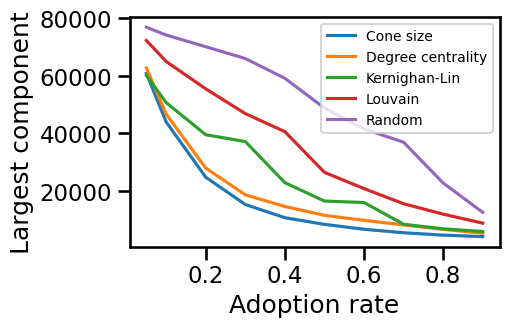

In [53]:
fig, ax = plt.subplots(figsize=(5, 3.2))
sns.lineplot(df, x="adoption_rate", y="max_component", hue="method")
plt.xlabel("Adoption rate")
plt.ylabel("Largest component")
plt.legend(fontsize=10, title_fontsize=12)
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/max_component.pdf", format="pdf")

In [40]:
df = pd.read_csv("test.csv")

df_long = df[["Rate", "Total", "Direct", "Indirect"]].melt(
    # 'id_vars' are the columns you want to keep as they are (e.g., an ID, date, etc.)
    # If you have none, you can omit this argument entirely.
    id_vars=['Rate'], 
    
    # 'value_vars' are the columns you want to turn into rows
    value_vars=["Total", "Direct", "Indirect"],
    
    # Name for the new column that will hold the old column names
    var_name='type',
    
    # Name for the new column that will hold the actual numbers
    value_name='impact_value' 
)

# 2. Rename the labels in the 'type' column to match what you want

print(df_long)


    Rate      type  impact_value
0    0.1     Total         0.910
1    0.2     Total         0.840
2    0.3     Total         0.780
3    0.4     Total         0.690
4    0.5     Total         0.590
5    0.6     Total         0.370
6    0.7     Total         0.150
7    0.8     Total         0.080
8    0.9     Total         0.010
9    0.1    Direct         0.770
10   0.2    Direct         0.610
11   0.3    Direct         0.460
12   0.4    Direct         0.330
13   0.5    Direct         0.200
14   0.6    Direct         0.110
15   0.7    Direct         0.030
16   0.8    Direct         0.015
17   0.9    Direct         0.005
18   0.1  Indirect         0.140
19   0.2  Indirect         0.230
20   0.3  Indirect         0.320
21   0.4  Indirect         0.360
22   0.5  Indirect         0.390
23   0.6  Indirect         0.260
24   0.7  Indirect         0.120
25   0.8  Indirect         0.065
26   0.9  Indirect         0.005


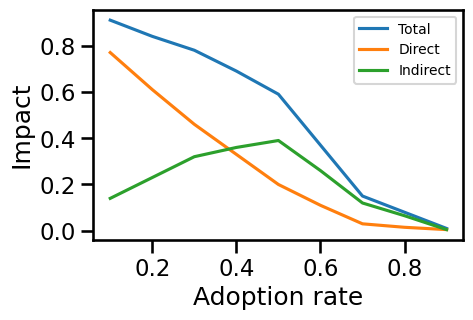

In [42]:
# %%
fig, ax = plt.subplots(figsize=(5, 3.2))
# Group by 'adoption_rate' and sample 500 rows from each group
# If you want to reset the index after sampling:

sns.lineplot(
    df_long, 
    x="Rate", 
    y="impact_value", 
    hue="type", 
#    style="type", 
#    markers=True, 
#    dashes=True
)

plt.ylabel("Impact")
plt.xlabel("Adoption rate")
plt.legend(fontsize=10, title_fontsize=12)
fig.subplots_adjust(
    left=0.22,
    right=0.96,
    bottom=0.22,
    top=0.94
)
plt.savefig("figures/impact.pdf", format="pdf")